# 04 - Resumen profundo: Custom Datasets, Loss Curves, Inferencia y Metricas

Este cuaderno resume y profundiza el modulo 04 con foco en:
- Punto 5: crear y entender un Dataset personalizado.
- Punto 8: interpretar curvas de perdida para detectar underfitting y overfitting.
- Punto 11: hacer inferencia sobre imagen personalizada sin errores de dtype, shape y device.
- Metricas clave: train_loss, test_loss, train_acc, test_acc, precision, recall, F1 y matriz de confusion.

Objetivo: que puedas ejecutar todo de arriba abajo y usarlo como plantilla para proyectos propios.

In [26]:
# Setup
import os
import random
import pathlib
from pathlib import Path
from typing import Dict, List, Tuple

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torchvision

import matplotlib.pyplot as plt
from PIL import Image

torch.manual_seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Torch: {torch.__version__}')
print(f'Device: {device}')

Torch: 2.12.0+cu126
Device: cuda


In [27]:
import requests
import zipfile
from pathlib import Path

# Setup portable paths (Windows-friendly)
project_root = Path.cwd()
data_candidates = [project_root / "data", project_root.parent / "data"]

# Pick the first candidate that already contains a valid dataset
data_path = None
for candidate in data_candidates:
    if (candidate / "pizza_steak_sushi" / "train").is_dir() and (candidate / "pizza_steak_sushi" / "test").is_dir():
        data_path = candidate
        break

if data_path is None:
    data_path = data_candidates[0]

image_path = data_path / "pizza_steak_sushi"
train_dir = image_path / "train"
test_dir = image_path / "test"

# Ensure data directory exists
data_path.mkdir(parents=True, exist_ok=True)

# Download only if valid train/test structure is missing
if train_dir.is_dir() and test_dir.is_dir():
    print(f"{image_path} directory exists and is valid.")
else:
    print(f"Did not find a valid dataset at {image_path}, creating/downloading...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

print(f"Data path in use: {data_path}")
print(f"Train dir exists: {train_dir.is_dir()}")
print(f"Test dir exists: {test_dir.is_dir()}")

c:\Users\egull\OneDrive\Documentos\Proyectos\pytorch-deep-learning\data\pizza_steak_sushi directory exists and is valid.
Data path in use: c:\Users\egull\OneDrive\Documentos\Proyectos\pytorch-deep-learning\data
Train dir exists: True
Test dir exists: True


## Punto 5 - Dataset personalizado en profundidad

Cuando ImageFolder no encaja con tu caso real, necesitas controlar completamente:
1. Como se obtiene la ruta de cada muestra.
2. Como se carga la imagen.
3. Como se asigna la etiqueta numerica.
4. Que transformaciones se aplican.

En PyTorch, un Dataset custom se apoya en dos metodos clave: __len__ y __getitem__.

In [28]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f'No se encontraron clases en {directory}')
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

classes, class_to_idx = find_classes(train_dir)
classes, class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [29]:
class ImageFolderCustom(Dataset):
    def __init__(self, targ_dir: str, transform=None) -> None:
        self.paths = list(pathlib.Path(targ_dir).glob('*/*.jpg'))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)

    def load_image(self, index: int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path).convert('RGB')

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            img = self.transform(img)
        return img, class_idx

train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_data_custom = ImageFolderCustom(train_dir, transform=train_transforms)
test_data_custom = ImageFolderCustom(test_dir, transform=test_transforms)

print('Train custom size:', len(train_data_custom))
print('Test custom size:', len(test_data_custom))
print('Classes:', train_data_custom.classes)

Train custom size: 225
Test custom size: 75
Classes: ['pizza', 'steak', 'sushi']


In [30]:
# Comparacion rapida con ImageFolder
train_data_ref = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_data_ref = datasets.ImageFolder(root=test_dir, transform=test_transforms)

print('Mismo len train:', len(train_data_custom) == len(train_data_ref))
print('Mismo len test:', len(test_data_custom) == len(test_data_ref))
print('Mismas clases:', train_data_custom.classes == train_data_ref.classes)
print('Mismo mapeo:', train_data_custom.class_to_idx == train_data_ref.class_to_idx)

Mismo len train: True
Mismo len test: True
Mismas clases: True
Mismo mapeo: True


### Mini ejercicio Punto 5
1. Modifica el Dataset para aceptar .jpeg y .png ademas de .jpg.
2. Agrega una verificacion para saltar imagenes corruptas.
3. Devuelve tambien la ruta junto con (imagen, etiqueta).

In [31]:
# DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 0  # En Windows, empezar en 0 evita varios problemas de multiprocessing

train_loader = DataLoader(train_data_custom, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_data_custom, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

X_batch, y_batch = next(iter(train_loader))
print('Batch X shape:', X_batch.shape)
print('Batch y shape:', y_batch.shape)
print('Batch dtype:', X_batch.dtype)

Batch X shape: torch.Size([32, 3, 64, 64])
Batch y shape: torch.Size([32])
Batch dtype: torch.float32


## Modelo base y entrenamiento corto para analisis de curvas

Entrenaremos pocas epocas para generar resultados y practicar lectura de metricas.

In [32]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 16 * 16, output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

model = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [33]:
def train_step(model, dataloader, loss_fn, optimizer):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y_logits = model(X)
        loss = loss_fn(y_logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
        train_acc += (y_pred == y).float().mean().item()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

def test_step(model, dataloader, loss_fn):
    model.eval()
    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_logits = model(X)
            loss = loss_fn(y_logits, y)

            test_loss += loss.item()
            y_pred = torch.argmax(y_logits, dim=1)
            test_acc += (y_pred == y).float().mean().item()

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc

def train(model, train_loader, test_loader, loss_fn, optimizer, epochs=5):
    results = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model, train_loader, loss_fn, optimizer)
        test_loss, test_acc = test_step(model, test_loader, loss_fn)

        results['train_loss'].append(train_loss)
        results['train_acc'].append(train_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)

        print(f'Epoch {epoch+1}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} test_loss={test_loss:.4f} test_acc={test_acc:.4f}')
    return results

results = train(model, train_loader, test_loader, loss_fn, optimizer, epochs=5)

Epoch 1: train_loss=1.1041 train_acc=0.3047 test_loss=1.1005 test_acc=0.2604
Epoch 2: train_loss=1.1021 train_acc=0.3203 test_loss=1.0898 test_acc=0.5417
Epoch 3: train_loss=1.0989 train_acc=0.2812 test_loss=1.0934 test_acc=0.5417
Epoch 4: train_loss=1.0972 train_acc=0.3008 test_loss=1.0924 test_acc=0.2604
Epoch 5: train_loss=1.0826 train_acc=0.4297 test_loss=1.0985 test_acc=0.2604


## Punto 8 - Interpretacion profunda de loss curves

Lectura rapida:
- Underfitting: train_loss y test_loss altos, accuracy baja en ambos.
- Overfitting: train_loss baja mucho, test_loss no acompana o sube; gap grande.
- Escenario ideal: ambas perdidas bajan y se mantienen cercanas.

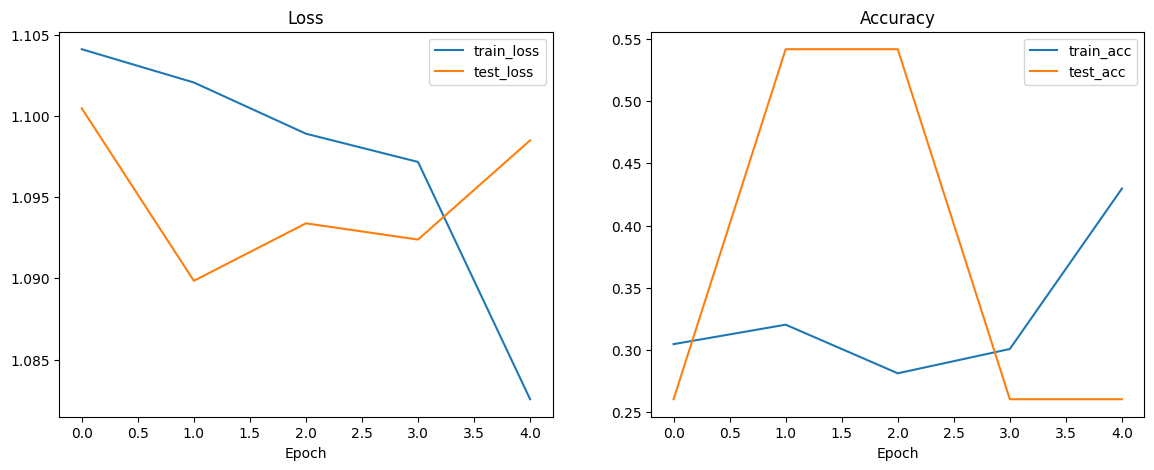

In [34]:
def plot_loss_curves(results: Dict[str, List[float]]):
    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, results['train_loss'], label='train_loss')
    plt.plot(epochs, results['test_loss'], label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, results['train_acc'], label='train_acc')
    plt.plot(epochs, results['test_acc'], label='test_acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

plot_loss_curves(results)

### Mini ejercicio Punto 8
1. Entrena 20 epocas y compara el gap train/test.
2. Duplica hidden_units y evalua si mejora o empeora la generalizacion.
3. Explica si tu comportamiento final es underfitting u overfitting y por que.

## Punto 11 - Inferencia sobre imagen personalizada

Los 3 errores clasicos en inferencia:
1. dtype incorrecto (uint8 en vez de float32).
2. device distinto entre modelo y tensor.
3. shape incorrecta (CHW en vez de NCHW).

In [35]:
import requests

custom_image_path = data_path / '04-pizza-dad.jpeg'
if not custom_image_path.is_file():
    url = 'https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg'
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    custom_image_path.write_bytes(r.content)
    print('Imagen descargada en', custom_image_path)
else:
    print('Imagen ya existe en', custom_image_path)

custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
print('Original dtype:', custom_image_uint8.dtype)
print('Original shape:', custom_image_uint8.shape)

Imagen ya existe en c:\Users\egull\OneDrive\Documentos\Proyectos\pytorch-deep-learning\data\04-pizza-dad.jpeg
Original dtype: torch.uint8
Original shape: torch.Size([3, 4032, 3024])


In [36]:
# Preprocesado correcto para inferencia
infer_transform = transforms.Compose([
    transforms.Resize((64, 64))
])

custom_image = custom_image_uint8.type(torch.float32) / 255.0
custom_image = infer_transform(custom_image)
custom_image = custom_image.unsqueeze(0)  # NCHW

print('Infer dtype:', custom_image.dtype)
print('Infer shape:', custom_image.shape)
print('Model device:', next(model.parameters()).device)

Infer dtype: torch.float32
Infer shape: torch.Size([1, 3, 64, 64])
Model device: cuda:0


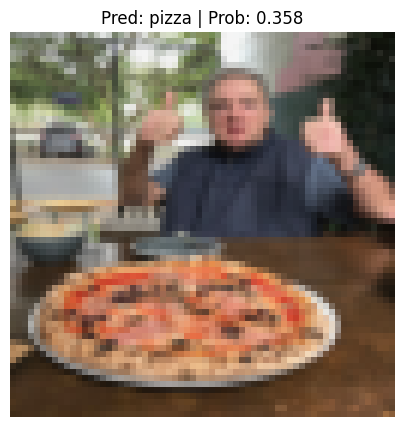

In [37]:
# Prediccion
model.eval()
with torch.inference_mode():
    logits = model(custom_image.to(device))
    probs = torch.softmax(logits, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()

pred_class = classes[pred_idx]
pred_conf = probs[0, pred_idx].item()

plt.figure(figsize=(5, 5))
plt.imshow(custom_image.squeeze(0).permute(1, 2, 0).cpu())
plt.title(f'Pred: {pred_class} | Prob: {pred_conf:.3f}')
plt.axis('off')
plt.show()

### Mini ejercicio Punto 11
1. Prueba con una imagen propia de pizza, steak o sushi.
2. Compara prediccion y confianza entre 3 imagenes distintas.
3. Explica cual de los 3 errores clasicos cometiste primero al probar por tu cuenta.

## Metricas principales y metricas extra

Ademas de loss y accuracy, en clasificacion multiclase conviene mirar precision, recall y F1 por clase.
Abajo calculamos estas metricas sin dependencias externas.

In [38]:
def get_all_preds_and_targets(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.inference_mode():
        for X, y in dataloader:
            X = X.to(device)
            logits = model(X)
            preds = torch.argmax(logits, dim=1).cpu()
            all_preds.append(preds)
            all_targets.append(y.cpu())
    return torch.cat(all_preds), torch.cat(all_targets)

def confusion_matrix_torch(preds: torch.Tensor, targets: torch.Tensor, num_classes: int):
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for t, p in zip(targets, preds):
        cm[t.long(), p.long()] += 1
    return cm

def precision_recall_f1_from_cm(cm: torch.Tensor):
    eps = 1e-12
    tp = torch.diag(cm).float()
    fp = cm.sum(dim=0).float() - tp
    fn = cm.sum(dim=1).float() - tp

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    return precision, recall, f1

preds, targets = get_all_preds_and_targets(model, test_loader, device)
cm = confusion_matrix_torch(preds, targets, num_classes=len(classes))
precision, recall, f1 = precision_recall_f1_from_cm(cm)

print('Confusion matrix:')
print(cm)
print()
for i, c in enumerate(classes):
    print(f'{c:>8} | precision={precision[i]:.3f} recall={recall[i]:.3f} f1={f1[i]:.3f}')

print()
print('Macro precision:', precision.mean().item())
print('Macro recall   :', recall.mean().item())
print('Macro F1       :', f1.mean().item())

Confusion matrix:
tensor([[25,  0,  0],
        [19,  0,  0],
        [31,  0,  0]])

   pizza | precision=0.333 recall=1.000 f1=0.500
   steak | precision=0.000 recall=0.000 f1=0.000
   sushi | precision=0.000 recall=0.000 f1=0.000

Macro precision: 0.1111111119389534
Macro recall   : 0.3333333432674408
Macro F1       : 0.1666666716337204


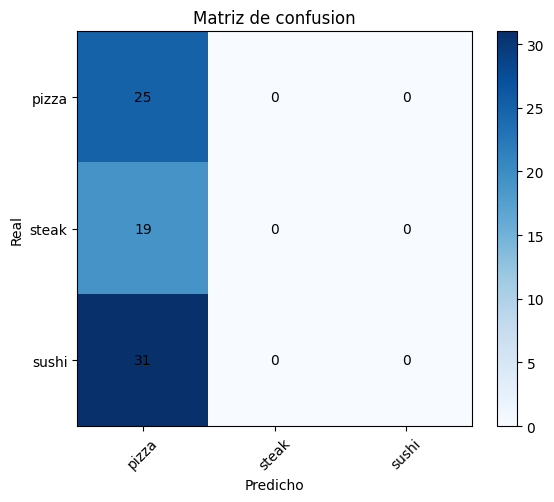

In [39]:
# Visualizacion de matriz de confusion
plt.figure(figsize=(6, 5))
plt.imshow(cm.numpy(), cmap='Blues')
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusion')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha='center', va='center')

plt.tight_layout()
plt.show()

### Mini ejercicio Metricas
1. Compara macro F1 entre modelo sin y con data augmentation.
2. Detecta la clase mas dificil segun recall.
3. Propone una accion concreta para mejorar esa clase (datos, transform o modelo).

## Checklist rapido de debugging (Windows friendly)
- Verifica rutas con Path y evita hardcodeos del sistema.
- Si falla DataLoader en Windows, usa num_workers=0.
- Si aparece error de tipos, revisa uint8 vs float32 y normalizacion [0,1].
- Si aparece error de shape, revisa CHW vs NCHW y usa unsqueeze(0).
- Si aparece error de device, mueve tanto modelo como tensores al mismo device.

Con esto tienes una plantilla reusable para tus propios datasets y tareas de clasificacion.

# 04 Resumen Deep Dive: Custom Datasets en PyTorch

Este notebook resume y profundiza el flujo de `04_pytorch_custom_datasets.ipynb` con foco en:

1. Punto 5: Custom `Dataset` (como funciona internamente).
2. Punto 8: Loss curves (underfitting vs overfitting).
3. Punto 11: Prediccion en imagen propia (inferencia real).
4. Metricas clave: `train_loss`, `test_loss`, `train_acc`, `test_acc`, `precision`, `recall`, `F1`.

Incluye mini ejercicios al final de cada bloque y recomendaciones especificas para Windows.

## 0) Setup y chequeo de entorno

Objetivo: dejar listo un entorno reproducible y portable en Windows.

In [40]:
import os
import pathlib
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Torch: {torch.__version__}")
print(f"Device: {device}")

# Recomendado en Windows para evitar problemas de multiprocessing
NUM_WORKERS = 0
BATCH_SIZE = 32

Torch: 2.12.0+cu126
Device: cuda


In [41]:
# Rutas portables
project_root = Path.cwd()
data_path = project_root / "data"
image_path = data_path / "pizza_steak_sushi"
train_dir = image_path / "train"
test_dir = image_path / "test"

if not image_path.is_dir():
    print("Dataset no encontrado. Descargando...")
    image_path.mkdir(parents=True, exist_ok=True)
    zip_target = data_path / "pizza_steak_sushi.zip"
    with open(zip_target, "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        f.write(request.content)
    with zipfile.ZipFile(zip_target, "r") as zip_ref:
        zip_ref.extractall(image_path)

print(f"Train dir existe: {train_dir.is_dir()}")
print(f"Test dir existe: {test_dir.is_dir()}")

Train dir existe: False
Test dir existe: False


## 1) Punto 5 - Custom Dataset a profundidad

### Idea central
Un `Dataset` custom te da control total sobre:
- como lees cada muestra,
- como obtienes su etiqueta,
- que transformaciones aplicas,
- que devuelves en `__getitem__`.

En PyTorch, lo minimo obligatorio es:
- `__len__`: cuantas muestras hay,
- `__getitem__`: como obtener una muestra por indice.

In [42]:
from typing import Dict, List, Tuple

def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Encuentra carpetas clase y crea el mapeo clase->indice."""
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"No se encontraron clases en {directory}")
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

classes, class_to_idx = find_classes(train_dir)
classes, class_to_idx

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'c:\\Users\\egull\\OneDrive\\Documentos\\Proyectos\\pytorch-deep-learning\\apuntes\\data\\pizza_steak_sushi\\train'

In [43]:
class ImageFolderCustom(Dataset):
    """Replica simple de ImageFolder para .jpg en estructura clase/imagen."""

    def __init__(self, targ_dir: str, transform=None) -> None:
        # Lista de rutas de imagen y metadatos de clases
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)

    def load_image(self, index: int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path).convert("RGB")

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform is not None:
            img = self.transform(img)

        return img, class_idx

In [44]:
# Transform base para comparar con ImageFolder
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_data_builtin = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_builtin = datasets.ImageFolder(root=test_dir, transform=simple_transform)

train_data_custom = ImageFolderCustom(targ_dir=train_dir, transform=simple_transform)
test_data_custom = ImageFolderCustom(targ_dir=test_dir, transform=simple_transform)

print("Misma longitud train:", len(train_data_builtin) == len(train_data_custom))
print("Misma longitud test:", len(test_data_builtin) == len(test_data_custom))
print("Mismas clases:", train_data_builtin.classes == train_data_custom.classes)
print("Mismo class_to_idx:", train_data_builtin.class_to_idx == train_data_custom.class_to_idx)

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'c:\\Users\\egull\\OneDrive\\Documentos\\Proyectos\\pytorch-deep-learning\\apuntes\\data\\pizza_steak_sushi\\train'

In [45]:
# DataLoaders con dataset custom
train_loader_custom = DataLoader(train_data_custom, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader_custom = DataLoader(test_data_custom, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

X_batch, y_batch = next(iter(train_loader_custom))
print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

X batch shape: torch.Size([32, 3, 64, 64])
y batch shape: torch.Size([32])


### Mini ejercicio (Punto 5)
1. Modifica `ImageFolderCustom` para aceptar tambien `.png` y `.jpeg`.
2. Agrega una validacion para ignorar imagenes corruptas (try/except en `load_image`).
3. Devuelve tambien la ruta en `__getitem__` y ajusta el `DataLoader` para inspeccion.

## 2) Bloque de entrenamiento minimo para curvas y metricas

Usaremos una version compacta de TinyVGG para generar resultados medibles.

In [47]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [48]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0.0, 0.0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y_logits = model(X)
        loss = loss_fn(y_logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
        train_acc += (y_pred == y).sum().item() / len(y)

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc


def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0.0, 0.0

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_logits = model(X)
            loss = loss_fn(y_logits, y)

            test_loss += loss.item()
            y_pred = torch.argmax(y_logits, dim=1)
            test_acc += (y_pred == y).sum().item() / len(y_pred)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc


def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device, epochs=5):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}"
        )

    return results

In [49]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

model_1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=1e-3)

results = train(
    model=model_1,
    train_dataloader=train_loader_custom,
    test_dataloader=test_loader_custom,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=5,
)

Epoch 1/5 | train_loss: 1.1077 | train_acc: 0.2500 | test_loss: 1.1367 | test_acc: 0.2604
Epoch 2/5 | train_loss: 1.0848 | train_acc: 0.4062 | test_loss: 1.1647 | test_acc: 0.1979
Epoch 3/5 | train_loss: 1.1213 | train_acc: 0.2930 | test_loss: 1.1702 | test_acc: 0.1979
Epoch 4/5 | train_loss: 1.1216 | train_acc: 0.2930 | test_loss: 1.1422 | test_acc: 0.2292
Epoch 5/5 | train_loss: 1.0993 | train_acc: 0.3945 | test_loss: 1.0994 | test_acc: 0.2812


## 3) Punto 8 - Loss Curves e interpretacion

### Como leerlas rapido
- **Underfitting**: train/test loss altas, accuracy baja en ambos.
- **Overfitting**: train loss baja mucho pero test loss sube o no mejora (gap grande).
- **Escenario ideal**: train y test mejoran juntas, gap pequeno y estable.

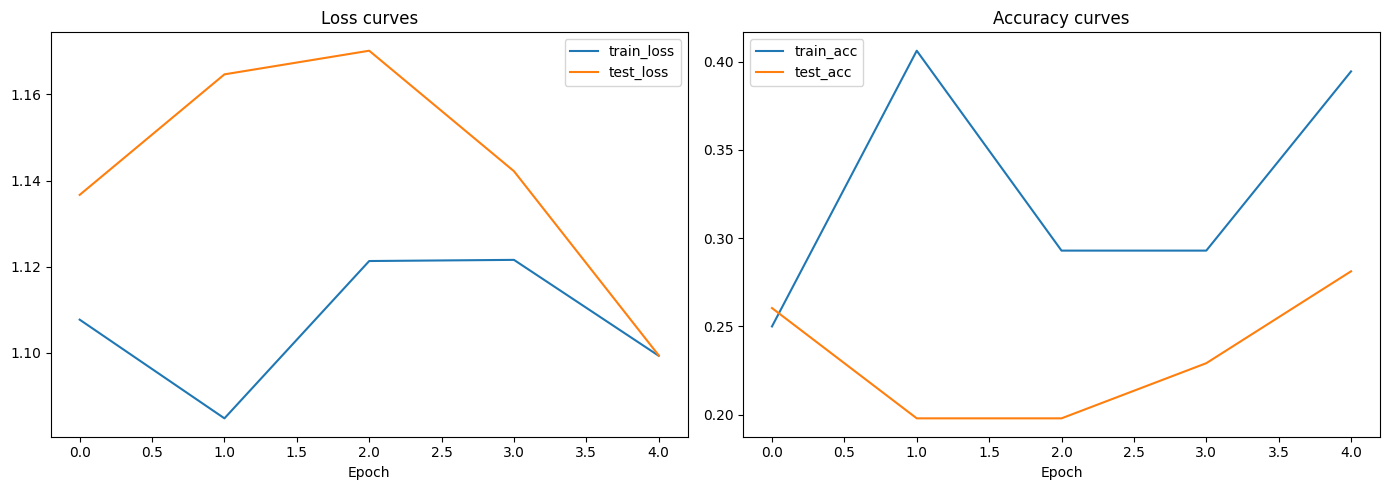

In [50]:
def plot_loss_curves(results_dict):
    train_loss = results_dict["train_loss"]
    test_loss = results_dict["test_loss"]
    train_acc = results_dict["train_acc"]
    test_acc = results_dict["test_acc"]
    epochs = range(len(train_loss))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss curves")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, test_acc, label="test_acc")
    plt.title("Accuracy curves")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()

plot_loss_curves(results)

### Mini ejercicio (Punto 8)
1. Entrena 10 epocas y compara el gap entre train/test loss.
2. Prueba `hidden_units=20` y describe si mejora underfitting.
3. Explica con una frase si tu corrida parece underfitting, overfitting o balanceada.

## 4) Punto 11 - Prediccion en imagen custom (inferencia real)

### Los 3 errores clasicos
1. `dtype` incorrecto: `uint8` vs `float32`.
2. `device` incorrecto: CPU vs GPU.
3. `shape` incorrecto: `CHW` vs `NCHW` (falta batch dimension).

In [51]:
import torchvision

custom_image_path = data_path / "04-pizza-dad.jpeg"
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        req = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        f.write(req.content)

custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
print("dtype original:", custom_image_uint8.dtype)
print("shape original:", custom_image_uint8.shape)

dtype original: torch.uint8
shape original: torch.Size([3, 4032, 3024])


In [52]:
# Preprocesado correcto: float32, [0,1], resize, batch, device
custom_image = custom_image_uint8.type(torch.float32) / 255.0
custom_transform = transforms.Compose([transforms.Resize((64, 64))])
custom_image = custom_transform(custom_image)
custom_image_batch = custom_image.unsqueeze(0).to(device)

print("dtype final:", custom_image_batch.dtype)
print("shape final:", custom_image_batch.shape)
print("device final:", custom_image_batch.device)

dtype final: torch.float32
shape final: torch.Size([1, 3, 64, 64])
device final: cuda:0


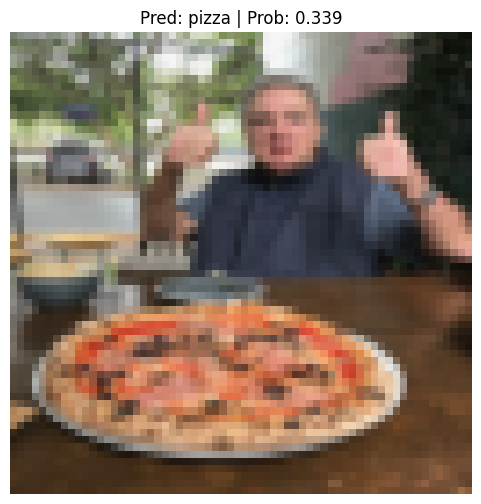

In [53]:
def pred_and_plot_image(model, image_path, class_names, transform=None, device="cpu"):
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32) / 255.0
    if transform is not None:
        target_image = transform(target_image)

    model.to(device)
    model.eval()
    with torch.inference_mode():
        target_image = target_image.unsqueeze(0).to(device)
        pred_logits = model(target_image)
        pred_probs = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_probs, dim=1)

    plt.figure(figsize=(6, 6))
    plt.imshow(target_image.squeeze().cpu().permute(1, 2, 0))
    plt.axis(False)
    pred_class = class_names[pred_label.cpu()]
    conf = pred_probs.max().item()
    plt.title(f"Pred: {pred_class} | Prob: {conf:.3f}")

pred_and_plot_image(
    model=model_1,
    image_path=custom_image_path,
    class_names=classes,
    transform=custom_transform,
    device=device,
)

### Mini ejercicio (Punto 11)
1. Prueba una imagen tuya de pizza/steak/sushi y anota la confianza.
2. Si falla, revisa en orden: dtype -> device -> shape -> transform.
3. Explica si el error parece de modelo (underfitting) o de pipeline (preprocesado).

## 5) Metricas principales y metricas importantes

- `train_loss` y `test_loss`: error de entrenamiento y generalizacion.
- `train_acc` y `test_acc`: exactitud agregada por epoca.
- `precision`, `recall`, `F1`: utiles cuando una clase es mas dificil o hay desbalance.

In [55]:
# Instalar dependencias de metricas si faltan
try:
    from sklearn.metrics import classification_report, confusion_matrix
except ImportError:
    %pip install -q scikit-learn seaborn
    from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns

c:\Users\egull\OneDrive\Documentos\Proyectos\pytorch-deep-learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\egull\OneDrive\Documentos\Proyectos\pytorch-deep-learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\egull\OneDrive\Documentos\Proyectos\pytorch-deep-learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

              precision    recall  f1-score   support

       pizza     0.3380    0.9600    0.5000        25
       steak     0.7500    0.1579    0.2609        19
       sushi     0.0000    0.0000    0.0000        31

    accuracy                         0.3600        75
   macro avg     0.3627    0.3726    0.2536        75
weighted avg     0.3027    0.3600    0.2328        75



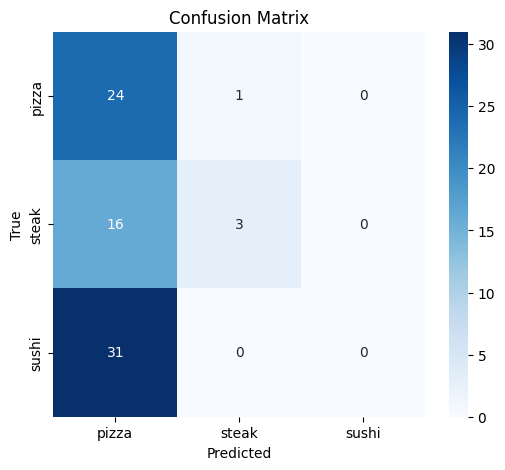

In [56]:
# Predicciones en test para precision/recall/F1 y confusion matrix
model_1.eval()
all_preds = []
all_targets = []

with torch.inference_mode():
    for X, y in test_loader_custom:
        X = X.to(device)
        logits = model_1(X)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(y.numpy().tolist())

print(classification_report(all_targets, all_preds, target_names=classes, digits=4))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### Mini ejercicio (Metricas)
1. Identifica la clase con peor recall y explica por que podria pasar.
2. Repite entrenamiento con mas epocas y compara F1 macro.
3. Responde: cuando usarias accuracy y cuando precision/recall/F1?

## 6) Checklist de debugging rapido

1. Si hay error de tipo: convierte imagen a `float32` y normaliza `[0,1]`.
2. Si hay error de device: mueve modelo y tensores al mismo `device`.
3. Si hay error de shape: recuerda `NCHW` y agrega `unsqueeze(0)`.
4. Si DataLoader falla en Windows: usa `num_workers=0`.
5. Si no aprende: revisa loss curves y decide entre underfitting/overfitting.

Con esto tienes un flujo completo y reusable para problemas de clasificacion de imagenes con PyTorch.